# 01: Look at This Thing

The notebook turns the chapter's Lenia spectacle into a measurable field process while preserving the warning that visual creature-language is provisional.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

from scipy.signal import fftconvolve


In [2]:
EXPERIMENT = {"seed": 5, "n": 160, "steps": 80, "dt": 0.18, "kernel_size": 41, "kernel_sigma": 7.0, "growth_mu": 0.165, "growth_sigma": 0.034}
EXPERIMENT


{'seed': 5,
 'n': 160,
 'steps': 80,
 'dt': 0.18,
 'kernel_size': 41,
 'kernel_sigma': 7.0,
 'growth_mu': 0.165,
 'growth_sigma': 0.034}

In [3]:
def gaussian_kernel(size, sigma):
    ax=np.arange(-(size//2), size//2+1); xx,yy=np.meshgrid(ax,ax); k=np.exp(-(xx**2+yy**2)/(2*sigma**2)); return k/k.sum()
def init_world(n, seed):
    rng=np.random.default_rng(seed); x=np.linspace(-1,1,n); y=np.linspace(-1,1,n); xx,yy=np.meshgrid(x,y); world=np.zeros((n,n), dtype=np.float32)
    def blob(cx,cy,sx,sy,amp): return amp*np.exp(-(((xx-cx)/sx)**2+((yy-cy)/sy)**2)/2)
    world += blob(-.05,0,.10,.07,.75)+blob(.08,0,.07,.05,.70)+blob(0,-.06,.05,.03,.40)+blob(-.12,.04,.04,.03,.22)+0.005*rng.random(world.shape)
    return np.clip(world,0,1)
def growth(u, mu, sigma): return 2*np.exp(-((u-mu)**2)/(2*sigma**2))-1
def shift_fractional(img, dx, dy):
    ny,nx=img.shape; fy=np.fft.fftfreq(ny); fx=np.fft.fftfreq(nx); phase=np.exp(-2j*np.pi*(fy[:,None]*dy+fx[None,:]*dx)); return np.fft.ifft2(np.fft.fft2(img)*phase).real.astype(np.float32)
def step(world, kernel, t):
    p=fftconvolve(world, kernel, mode="same"); world=np.clip(world + EXPERIMENT["dt"]*growth(p, EXPERIMENT["growth_mu"] + 0.004*math.sin(t*.05), EXPERIMENT["growth_sigma"]), 0, 1)
    gx=np.gradient(world, axis=1); gy=np.gradient(world, axis=0); return np.clip(shift_fractional(world, float(np.mean(gx*world)*-120), float(np.mean(gy*world)*-40)),0,1)
def mass_centroid(world):
    yy,xx=np.indices(world.shape); total=world.sum(); return (float((yy*world).sum()/total), float((xx*world).sum()/total), float(total))


## Baseline observation and measurement


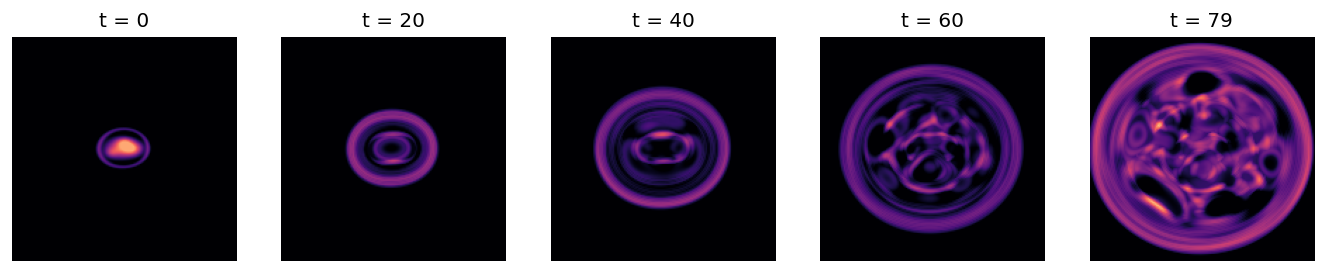

In [4]:
kernel=gaussian_kernel(EXPERIMENT["kernel_size"], EXPERIMENT["kernel_sigma"]); world=init_world(EXPERIMENT["n"], EXPERIMENT["seed"]); frames=[]; measures=[]
for t in range(EXPERIMENT["steps"]):
    world=step(world, kernel, t)
    if t in [0,20,40,60,79]: frames.append((t, world.copy()))
    measures.append(mass_centroid(world))
fig, axes = plt.subplots(1, len(frames), figsize=(14,3))
for ax,(t,frame) in zip(axes, frames): ax.imshow(frame, cmap="magma", vmin=0, vmax=1); ax.set_title(f"t = {t}"); ax.axis("off")
plt.show()


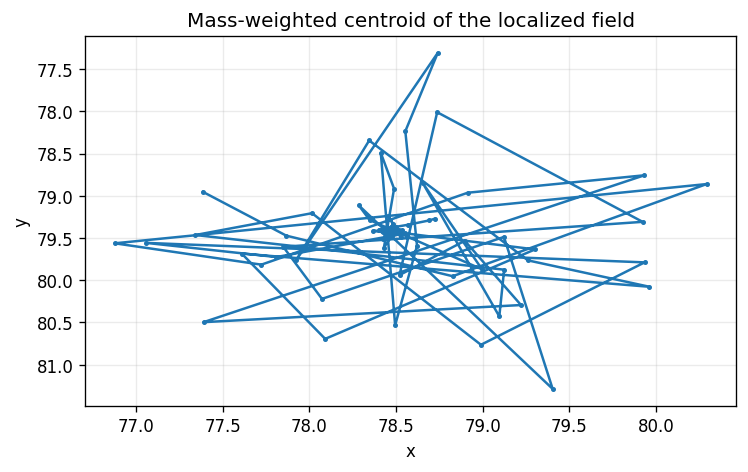

{'initial_mass': 260.58001708984375,
 'final_mass': 5462.486328125,
 'centroid_displacement': (-0.31769066092425646, -1.3401114656478086)}

In [5]:
m=np.array(measures); fig, ax = plt.subplots(figsize=(7,4)); ax.plot(m[:,1], m[:,0], marker="o", markersize=2); ax.invert_yaxis(); ax.set(title="Mass-weighted centroid of the localized field", xlabel="x", ylabel="y"); ax.grid(alpha=.25); plt.show()
{"initial_mass": float(m[0,2]), "final_mass": float(m[-1,2]), "centroid_displacement": (float(m[-1,0]-m[0,0]), float(m[-1,1]-m[0,1]))}


## What the evidence supports

A localized continuous field can deform and shift without any explicit creature variable. This is an observation plus operational measurements, not evidence of organismhood, agency, healing, or reproduction.

## Provenance

**Book chapter**

`content/books/digital-life/01-look-at-this-thing/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch01_lenia_animation.py`
- `scripts/books/digital-life/ch01_lenia_damage_triptych.py`
- `scripts/books/digital-life/ch01_lenia_fixed_grid.py`

**Book figures reproduced**

Inline Lenia-style frames and centroid measurements are recomputed. The fixed-grid book figure `static/images/books/digital-life/ch01-lenia-fixed-grid-motion.png` depends on browser capture from the official Lenia demo and is listed as provenance rather than recomputed here.
